In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- project imports ----
from sim.frame import make_blank_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.camera import Camera
from sim.lens import Lens
from sim.physics.noise import apply_noise

In [10]:
STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=500.0,
    f_number=2.0,
    transmission=0.9
)

jitter: 5.000" RMS => 3.232 px (plate=1.547"/px)


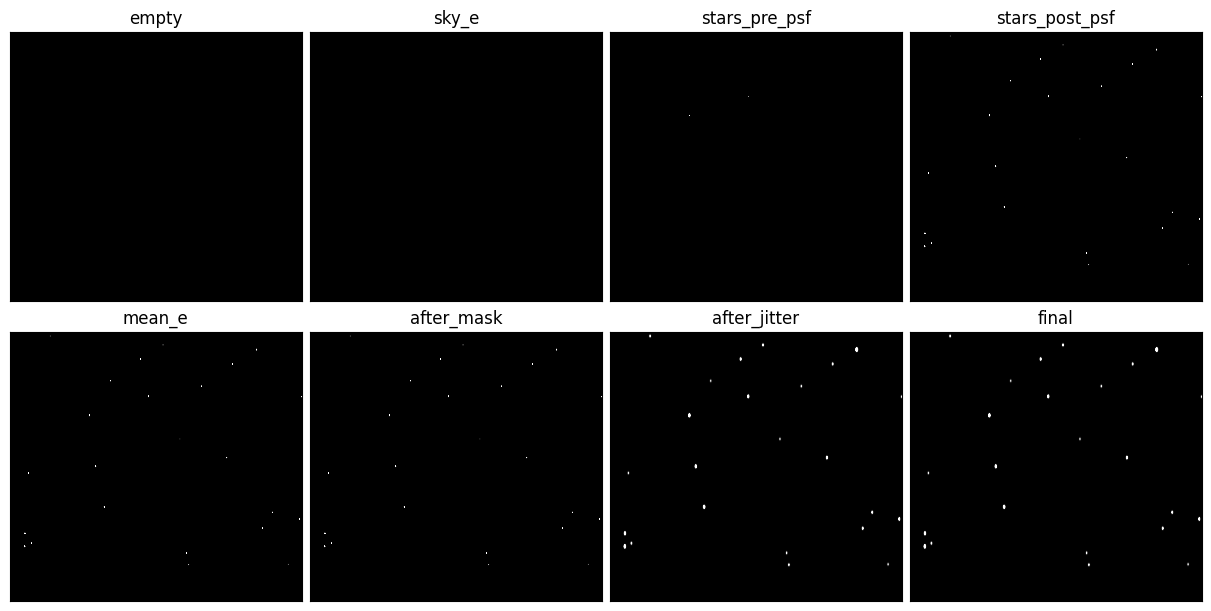

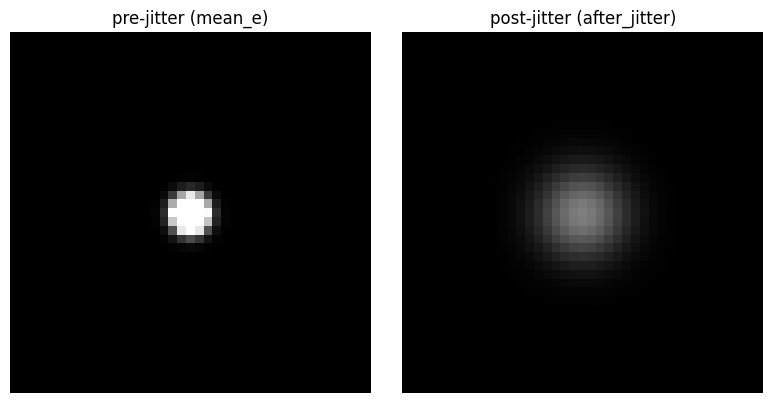

peak pre: 10521.0791015625 peak post: 1323.7930908203125


In [14]:
# ===============================
# JITTER TEST
# ===============================

cfg_nojit = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    psf_sigma_px=1.2,
    read_noise_e=0.0,
    jitter_pointing_rms=0,
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
    seed=7,
)

cfg_jit = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    psf_sigma_px=1.2,
    read_noise_e=0.0,
    jitter_pointing_rms=5,   # arcseconds/px
    enable_psf=True,
    enable_mask=False,
    enable_jitter=True,
    enable_noise=False,
    seed=7,
)

frameA = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frameA, resA = render(frameA, cfg_nojit, stars=STAR_CSV)

frameB = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frameB, resB = render(frameB, cfg_jit, stars=STAR_CSV)

# show stages for jitter-on (so you see after_jitter change)
plot_render_stages(frameB, resB, cmap="gray", stretch="asinh", shared_scale=True)

# zoom on brightest star: compare mean_e (pre-jitter) vs after_jitter_e
pre = resB.after_mask_e  # since mask disabled, this is mean_e
post = resB.after_jitter_e

y0, x0 = np.unravel_index(np.argmax(resB.stars_e_pre_psf), resB.stars_e_pre_psf.shape)
half = 20

cut_pre  = pre[y0-half:y0+half+1, x0-half:x0+half+1]
cut_post = post[y0-half:y0+half+1, x0-half:x0+half+1]

both = np.concatenate([cut_pre.ravel(), cut_post.ravel()])
vmin, vmax = np.percentile(both, [1, 99.7])

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(cut_pre, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
axs[0].set_title("pre-jitter (mean_e)")
axs[0].axis("off")

axs[1].imshow(cut_post, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
axs[1].set_title("post-jitter (after_jitter)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

print("peak pre:", float(np.max(cut_pre)), "peak post:", float(np.max(cut_post)))